In [ ]:
# Should be exec first in a fresh venv
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

# Imports

In [1]:
from scipy.stats import ttest_ind, ttest_rel
import anndata as ad
import scanpy as sc
import numpy as np
import os

from hygeia.utils.hplots import violin_plot

# Colors

In [2]:
label_color_dict = {
    f'Non-infected': '#708090',
    f'Infected':'#FFC0CB',
    f'Predicted infected':'#d62728',
}

In [3]:
def get_violin(
    ood_cov, 
    save_path
    ):

    # Read original data
    adata_observed = sc.read_h5ad(
    '../../Datasets/preprocessed_datasets/liver.h5ad'
    )
    
    # Read prediction for OOD (Unseen infected zone)
    adata_pred = sc.read_h5ad(
        f'../../Benchmarks/SCDISENTANGLE/Liver/predictions/liver_infected/{ood_cov}_1.h5ad'
    )

    # Get median
    mask_train = adata_observed.obs[f'split_TRUE_{ood_cov}'] == 'train'
    train_median = np.median(
        adata_observed[mask_train].layers['counts'].sum(axis=1)
    )
    print('train_median', train_median)

    # Normalize original data
    sc.pp.normalize_total(adata_observed, target_sum=train_median)
    sc.pp.log1p(adata_observed)

    # Normalize prediction
    sc.pp.normalize_total(adata_pred, target_sum=train_median)
    sc.pp.log1p(adata_pred)
    
    # pred = (original cells are non-infected, zone=OOD, prediction is infected=TRUE)
    mask_pred = (
        (adata_pred.obs['infected_org'] == 'FALSE') & 
        (adata_pred.obs['zone'] == ood_cov) & 
        (adata_pred.obs['infected_pred'] == 'TRUE')
    )

    # gt is (infected=TRUE, zone=ood)
    mask_observed = (
        (adata_observed.obs['infected'] == 'TRUE') & 
        (adata_observed.obs['zone'] == ood_cov)
    )
    
    # ctrl is infected=FALSE, zone=ood
    mask_non_infected = (
        (adata_observed.obs['infected'] == 'FALSE') & 
        (adata_observed.obs['zone'] == ood_cov) & 
        (adata_observed.obs[f'split_TRUE_{ood_cov}'] == 'train')
    )

    # subset observed & pred
    adata_non_infected = adata_observed[mask_non_infected].copy()
    adata_observed_ood = adata_observed[mask_observed].copy()
    adata_pred_ood = adata_pred[mask_pred].copy()

    # TOP ood DEG
    top_deg = adata_observed.uns['rank_genes_groups_infected']['TRUE'][ood_cov][0]

    # Create label
    adata_non_infected.obs['custom_label'] = f'Non-infected'
    adata_observed_ood.obs['custom_label'] = f'Infected'
    adata_pred_ood.obs['custom_label'] = f'Predicted infected'

    # Concat
    adata_cat = ad.concat([
        adata_non_infected,
        adata_observed_ood, 
        adata_pred_ood
    ]
    )

    # Violin plot
    violin_plot(
        adata=adata_cat,
        variable_of_interest=top_deg,
        label_column_name='custom_label',
        title=f'{ood_cov} Cells',
        x_name='',
        y_name=f'{top_deg} Log expression',
        violin_color='Black',
        figsize=(3.08, 4.5),
        label_color_dict=label_color_dict,
        save_path=save_path,
        inner='quart',
        despine=True
    )

    # Align pred with control to run paired t-test
    ctrl = adata_non_infected
    gt = adata_observed_ood
    pred = adata_pred_ood

    pred_ids = pred.obs['sc_cell_ids'].to_numpy()
    ctrl_ids = ctrl.obs['sc_cell_ids'].to_numpy()

    ctrl_map = {cid: i for i, cid in enumerate(ctrl_ids)}
    ctrl_idx = [ctrl_map[cid] for cid in pred_ids]
    ctrl = ctrl[ctrl_idx].copy()

    assert ctrl.obs['sc_cell_ids'].tolist() == pred.obs['sc_cell_ids'].tolist()
    
    # Ttest between pred and gt
    ttest_pred_gt = ttest_ind(
        pred[:, top_deg].X.squeeze(),
        gt[:, top_deg].X.squeeze(),
        )

    # Ttest between pred and non-infected
    ttest_pred_ctrl = ttest_rel(
        pred[:, top_deg].X.squeeze(),
        ctrl[:, top_deg].X.squeeze()
    )

    print('ttest pred-gt', ttest_pred_gt)
    print('ttest pred-non-infected', ttest_pred_ctrl)

In [4]:
save_dir= f'{FIG_ROOT}/Liver/violinplots/'
os.makedirs(save_dir, exist_ok=True)

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
adata.X seems to be already log-transformed.


train_median 5928.8613


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


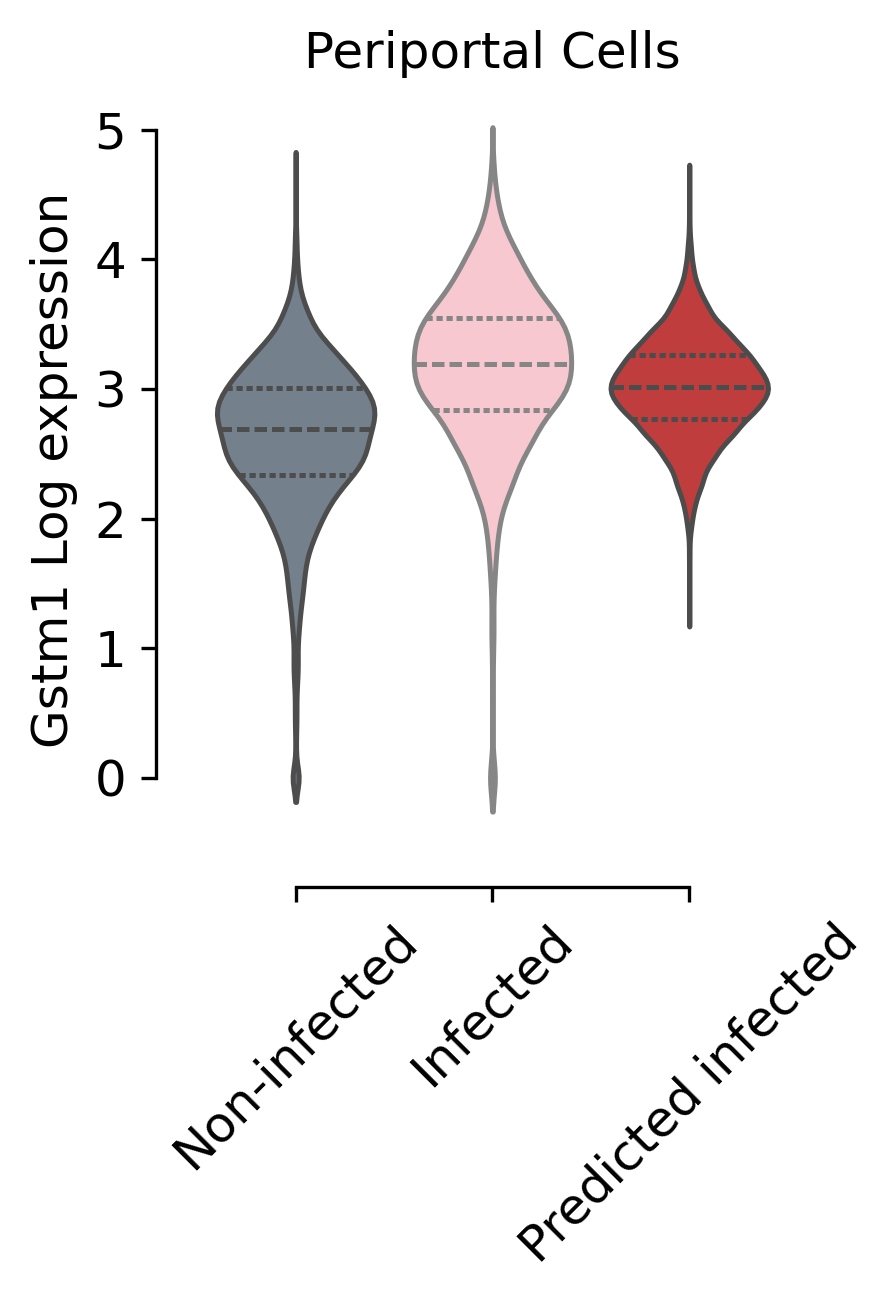

ttest pred-gt TtestResult(statistic=-14.98955294991589, pvalue=2.372017128343473e-50, df=12391.0)
ttest pred-non-infected TtestResult(statistic=81.48201179722977, pvalue=0.0, df=9837)


In [5]:
get_violin(ood_cov='Periportal', save_path=f'{save_dir}/Periportal')

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
adata.X seems to be already log-transformed.


train_median 6032.3276


/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


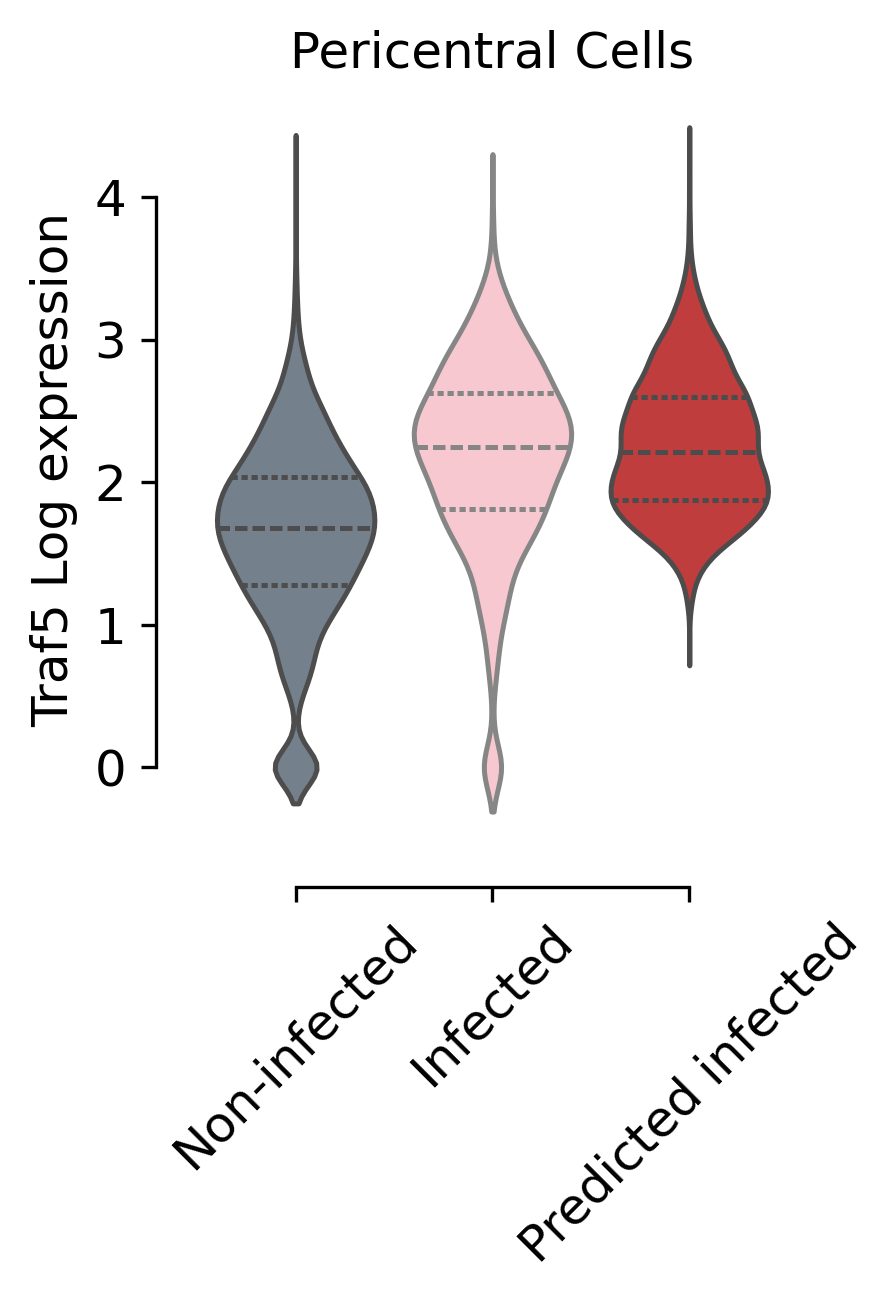

ttest pred-gt TtestResult(statistic=5.046785922710001, pvalue=4.6471923004389574e-07, df=5163.0)
ttest pred-non-infected TtestResult(statistic=59.19766923091704, pvalue=0.0, df=3610)


In [6]:
get_violin(ood_cov='Pericentral', save_path=f'{save_dir}/Pericentral')